In [ ]:
import numpy as np
import pandas as pd
import shap

# for plotting
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline

# Processor
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

# Fill in the missing values
from sklearn.impute import SimpleImputer

# Combine
from sklearn.compose import ColumnTransformer

# Model (skl) -> onnx
from skl2onnx import to_onnx

# Algorithm will be train to be a model
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Train/Test Split
from sklearn.model_selection import train_test_split

# Testing metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import classification_report # Shortcut for precision_score, recall_score and f1_score
from sklearn.metrics import confusion_matrix

: 

In [50]:
# 1: Get Datasets
# Load Datasets (Augmented)

df = pd.read_csv("datasets/maternal_care_datasets_augmented.csv")


In [51]:
df.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel,sleep_hours,phys_activity_score,stress_score,education_level,income_category,urban_rural,diet_quality_score,hemoglobin_g_dL,iron_supplement,folic_supplement,diet_adherence
0,25,130,80,15.0,98.0,86,high risk,8.04,8.23,3.99,Secondary,Medium,Urban,3.92,11.47,1,1,Fair
1,35,140,90,13.0,98.0,70,high risk,6.55,6.67,6.16,Secondary,Medium,Urban,3.95,11.88,1,1,Fair
2,29,90,70,8.0,100.0,80,high risk,6.07,9.30,4.51,Secondary,Low,Rural,2.00,10.32,1,1,Poor
3,30,140,85,7.0,98.0,70,high risk,5.86,6.11,3.86,Tertiary,High,Urban,6.05,11.74,1,0,Good
4,35,120,60,6.1,98.0,76,low risk,6.34,8.57,5.55,Secondary,Low,Rural,3.79,13.74,0,1,Fair


In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  1014 non-null   int64  
 1   SystolicBP           1014 non-null   int64  
 2   DiastolicBP          1014 non-null   int64  
 3   BS                   1014 non-null   float64
 4   BodyTemp             1014 non-null   float64
 5   HeartRate            1014 non-null   int64  
 6   RiskLevel            1014 non-null   str    
 7   sleep_hours          1014 non-null   float64
 8   phys_activity_score  1014 non-null   float64
 9   stress_score         1014 non-null   float64
 10  education_level      1014 non-null   str    
 11  income_category      1014 non-null   str    
 12  urban_rural          1014 non-null   str    
 13  diet_quality_score   1014 non-null   float64
 14  hemoglobin_g_dL      1014 non-null   float64
 15  iron_supplement      1014 non-null   int64  
 16 

In [53]:
df.describe()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,sleep_hours,phys_activity_score,stress_score,diet_quality_score,hemoglobin_g_dL,iron_supplement,folic_supplement
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775,6.619882,8.050848,4.582791,4.520503,12.203580,0.498028,0.625247
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702,0.916207,1.493150,1.544716,1.426268,1.085935,0.500243,0.484298
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000,3.510000,3.090000,0.220000,0.840000,8.210000,0.000000,0.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000,6.010000,7.000000,3.550000,3.540000,11.472500,0.000000,0.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000,6.600000,8.250000,4.525000,4.490000,12.205000,0.000000,1.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000,7.217500,9.217500,5.700000,5.517500,12.940000,1.000000,1.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000,9.310000,10.000000,9.460000,8.730000,16.000000,1.000000,1.000000


<Axes: >

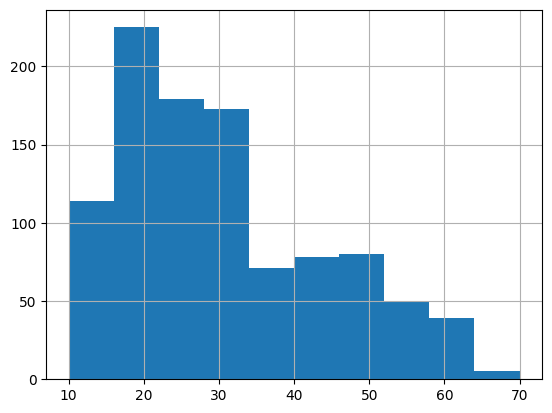

In [54]:
# 2: Exploratory Data Analysis (EDA)

# Age Analysis Distribution
df['Age'].hist()

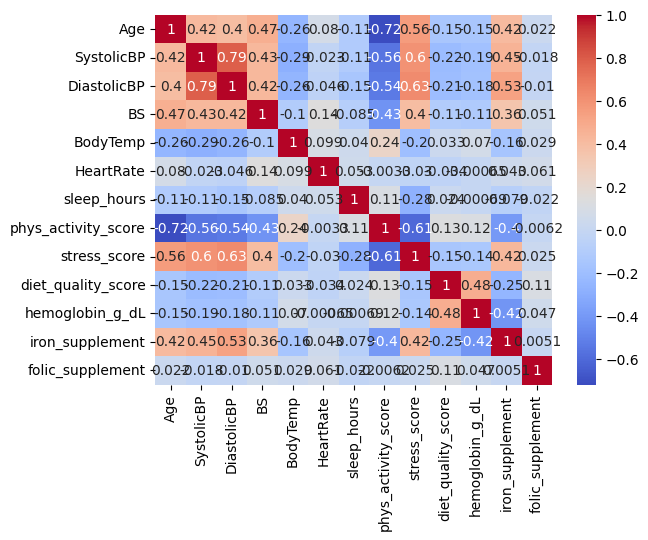

In [55]:
# Correlation between features

corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [56]:
# Risk Level Occurence

# Cunt
df['RiskLevel'].value_counts()

RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64

' Plot Below shows that: \n high risk has the least occurence, \n low risks has the highest occurence, and \n mid risk is in between in the datasets '

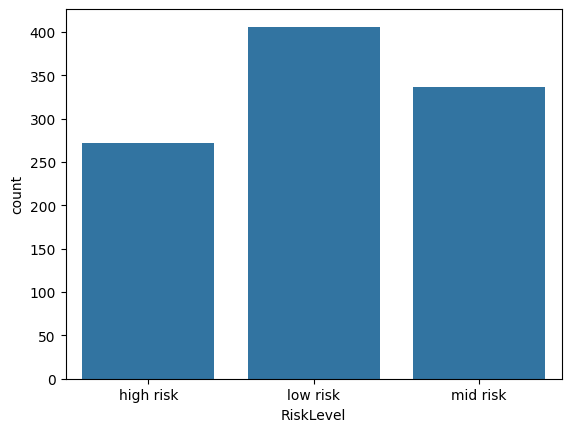

In [57]:
# Plot
sns.countplot(x='RiskLevel', data=df)

""" Plot Below shows that: 
 high risk has the least occurence, 
 low risks has the highest occurence, and 
 mid risk is in between in the datasets """

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'SystolicBP'}>,
        <Axes: title={'center': 'DiastolicBP'}>,
        <Axes: title={'center': 'BS'}>],
       [<Axes: title={'center': 'BodyTemp'}>,
        <Axes: title={'center': 'HeartRate'}>,
        <Axes: title={'center': 'sleep_hours'}>,
        <Axes: title={'center': 'phys_activity_score'}>],
       [<Axes: title={'center': 'stress_score'}>,
        <Axes: title={'center': 'diet_quality_score'}>,
        <Axes: title={'center': 'hemoglobin_g_dL'}>,
        <Axes: title={'center': 'iron_supplement'}>],
       [<Axes: title={'center': 'folic_supplement'}>, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

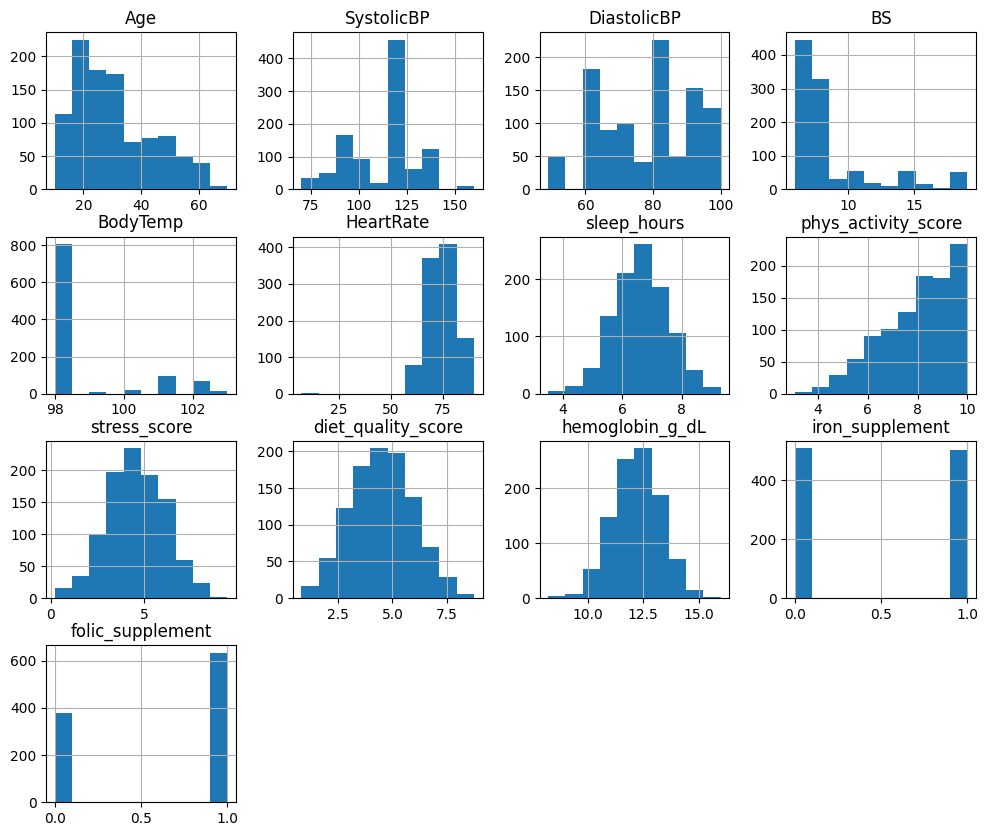

In [58]:
# Numeric Feature Distributions (Histograms)

# Mainly Focusing on this good stuff:
# Age
# Blood pressure
# HeartRate
# BodyTemp
# stress_score
# sleep_hours

df.hist(figsize=(12,10))

<Axes: xlabel='SystolicBP'>

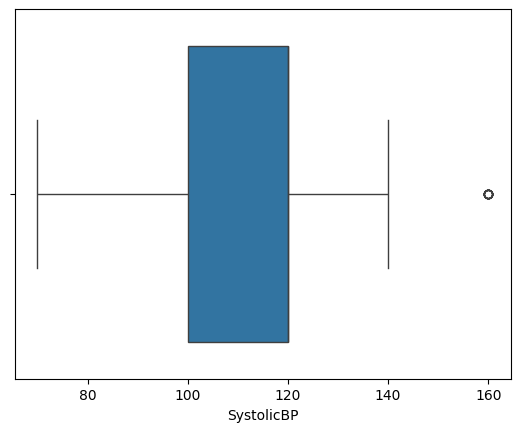

In [59]:
# Outliers (Boxplots)

# Important features:

# SystolicBP
# DiastolicBP
# HeartRate
# BodyTemp
# hemoglobin_g_dL

sns.boxplot(x=df['SystolicBP'])

<Axes: xlabel='DiastolicBP'>

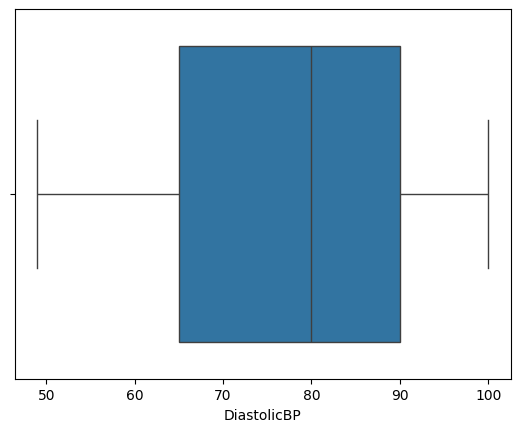

In [60]:
sns.boxplot(x=df['DiastolicBP'])

<Axes: xlabel='HeartRate'>

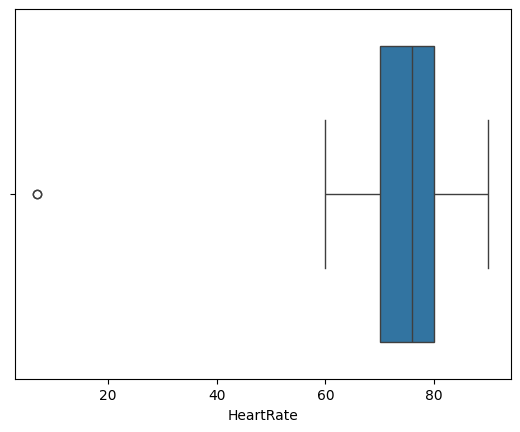

In [61]:
sns.boxplot(x=df['HeartRate'])

<Axes: xlabel='BodyTemp'>

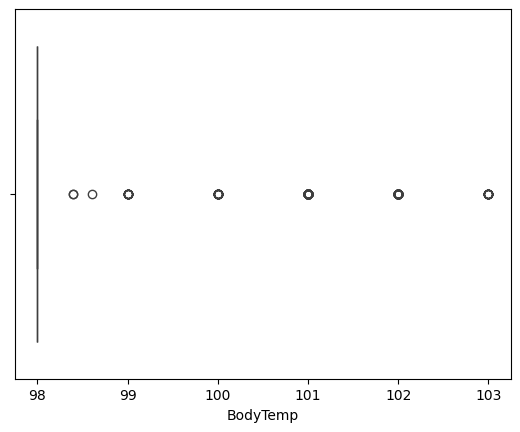

In [62]:
sns.boxplot(x=df['BodyTemp'])

<Axes: xlabel='hemoglobin_g_dL'>

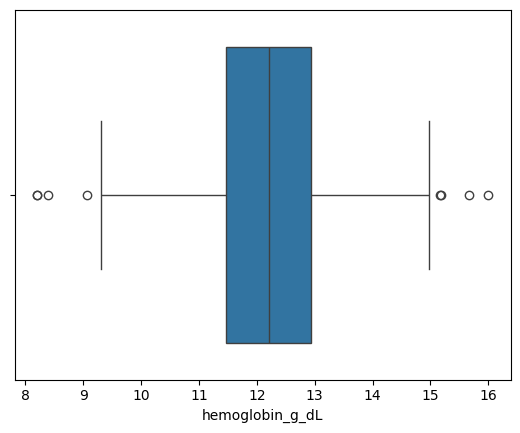

In [63]:
sns.boxplot(x=df['hemoglobin_g_dL'])

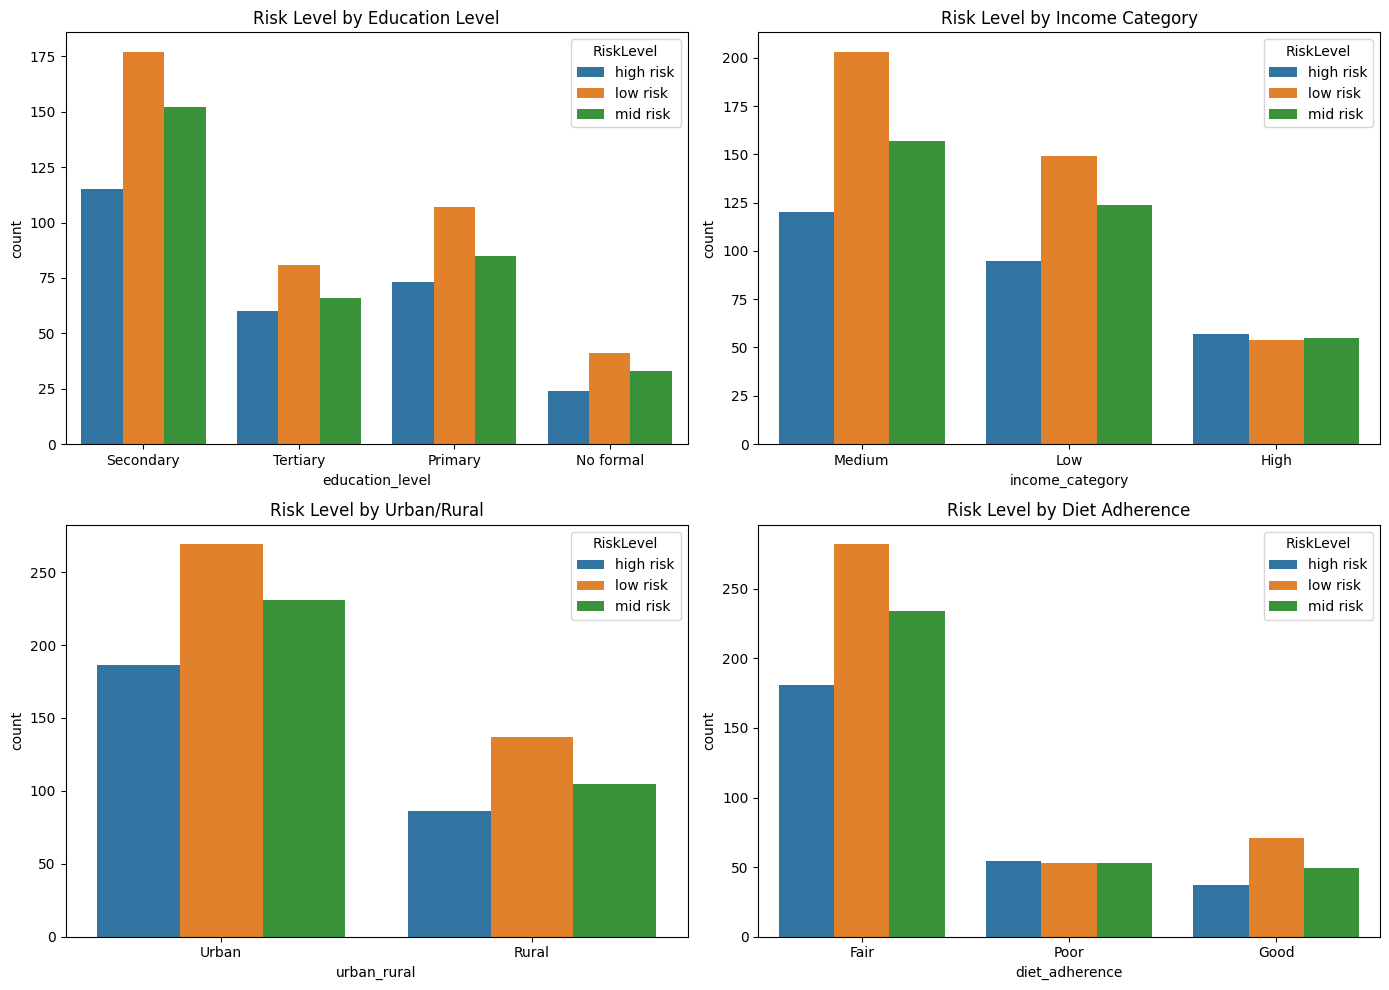

In [64]:
# Categorical Features Analysis

# education_level
# income_category
# urban_rural
# diet_adherence

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

# Top-Left plot
sns.countplot(x='education_level', hue='RiskLevel', data=df, ax=axes[0, 0])
axes[0, 0].set_title('Risk Level by Education Level')

# Top-Right plot
sns.countplot(x='income_category', hue='RiskLevel', data=df, ax=axes[0, 1])
axes[0, 1].set_title('Risk Level by Income Category')

# Bottom-Left plot
sns.countplot(x='urban_rural', hue='RiskLevel', data=df, ax=axes[1, 0])
axes[1, 0].set_title('Risk Level by Urban/Rural')

# Bottom-Right plot
sns.countplot(x='diet_adherence', hue='RiskLevel', data=df, ax=axes[1, 1])
axes[1, 1].set_title('Risk Level by Diet Adherence')

# Automatically adjust spacing between plots so titles and labels don't overlap
plt.tight_layout()

# Display the final combined plot
plt.show()

<Axes: xlabel='RiskLevel', ylabel='stress_score'>

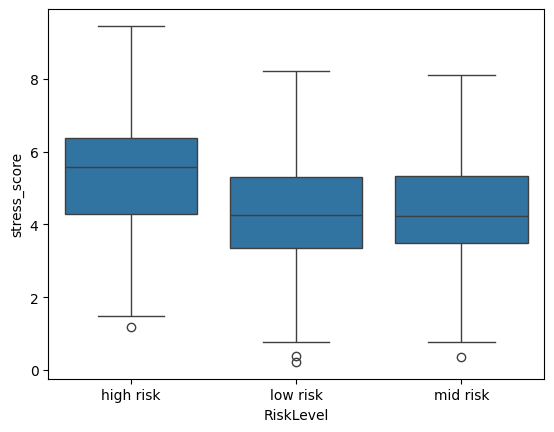

In [65]:
# Feature vs Target Analysis

# stress_score
# sleep_hours
# phys_activity_score
# diet_quality_score

sns.boxplot(x='RiskLevel', y='stress_score', data=df)

<Axes: xlabel='RiskLevel', ylabel='sleep_hours'>

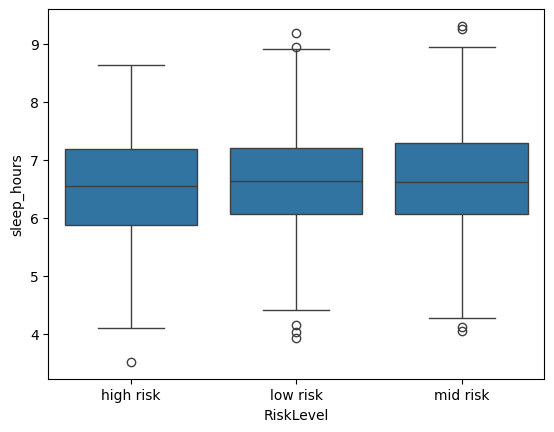

In [66]:
sns.boxplot(x='RiskLevel', y='sleep_hours', data=df)

<Axes: xlabel='RiskLevel', ylabel='phys_activity_score'>

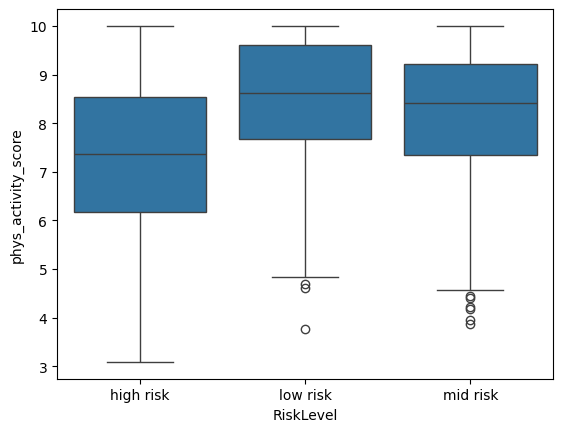

In [67]:
sns.boxplot(x='RiskLevel', y='phys_activity_score', data=df)

<Axes: xlabel='RiskLevel', ylabel='diet_quality_score'>

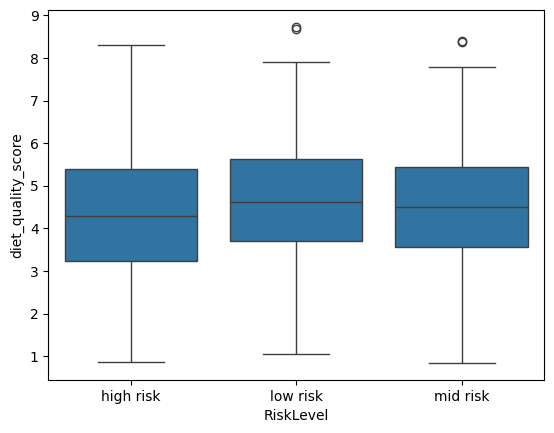

In [68]:
sns.boxplot(x='RiskLevel', y='diet_quality_score', data=df)

In [69]:
# 3: Data Preprocessing Design (IMPORTANT)

print('Numerical Features:')
print("""
Age
SystolicBP
DiastolicBP
BS
BodyTemp
HeartRate
sleep_hours
phys_activity_score
stress_score
diet_quality_score
hemoglobin_g_dL
iron_supplement
folic_supplement
""")

print('Categorical Features:')
print("""
education_level
income_category
urban_rural
diet_adherence
""")

print('Target:')
print('RiskLevel')

Numerical Features:

Age
SystolicBP
DiastolicBP
BS
BodyTemp
HeartRate
sleep_hours
phys_activity_score
stress_score
diet_quality_score
hemoglobin_g_dL
iron_supplement
folic_supplement

Categorical Features:

education_level
income_category
urban_rural
diet_adherence

Target:
RiskLevel


In [70]:
# Preprocessing Plan

# Numeric → fill with mean
# Categorical → fill with most frequent

num_imputer = SimpleImputer(strategy='mean')
cat_imputer = SimpleImputer(strategy='most_frequent')

# Encoding Categorical Data
encoder = OneHotEncoder(handle_unknown='ignore')

In [71]:
# Combine Everything

numeric_features = [
    'Age','SystolicBP','DiastolicBP','BS','BodyTemp','HeartRate',
    'sleep_hours','phys_activity_score','stress_score',
    'diet_quality_score','hemoglobin_g_dL',
    'iron_supplement','folic_supplement'
]

categorical_features = [
    'education_level','income_category','urban_rural','diet_adherence'
]

preprocessor = ColumnTransformer([
    ('num', num_imputer, numeric_features),
    ('cat', Pipeline([
        ('imputer', cat_imputer),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_features)
])

In [72]:
# Model Pipeline

# SVM
svm_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('scaler', StandardScaler()),
    ('model', SVC())
])

# Random Forest
rf_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier())
])

In [73]:
# Train-svm_pipeline.fit(X_train, y_train)

X = df.drop('RiskLevel', axis=1)
y = df['RiskLevel']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [74]:
# Train Model via Pipeline Created

# Random Forest
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [75]:
# Support Vector Machine

svm_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [76]:
# Predict
y_pred_svm = svm_pipeline.predict(X_test)
y_pred_rf = rf_pipeline.predict(X_test)

In [77]:
print("SVM:")
svm_report = classification_report(y_test, y_pred_svm)
print(svm_report)

SVM:
              precision    recall  f1-score   support

   high risk       0.91      0.75      0.82        55
    low risk       0.57      0.78      0.66        81
    mid risk       0.46      0.33      0.38        67

    accuracy                           0.62       203
   macro avg       0.65      0.62      0.62       203
weighted avg       0.63      0.62      0.61       203



In [78]:
print("Random Forest:")
rf_report = classification_report(y_test, y_pred_rf)
print(rf_report)

Random Forest:
              precision    recall  f1-score   support

   high risk       0.92      0.89      0.91        55
    low risk       0.64      0.80      0.71        81
    mid risk       0.59      0.43      0.50        67

    accuracy                           0.70       203
   macro avg       0.72      0.71      0.71       203
weighted avg       0.70      0.70      0.70       203



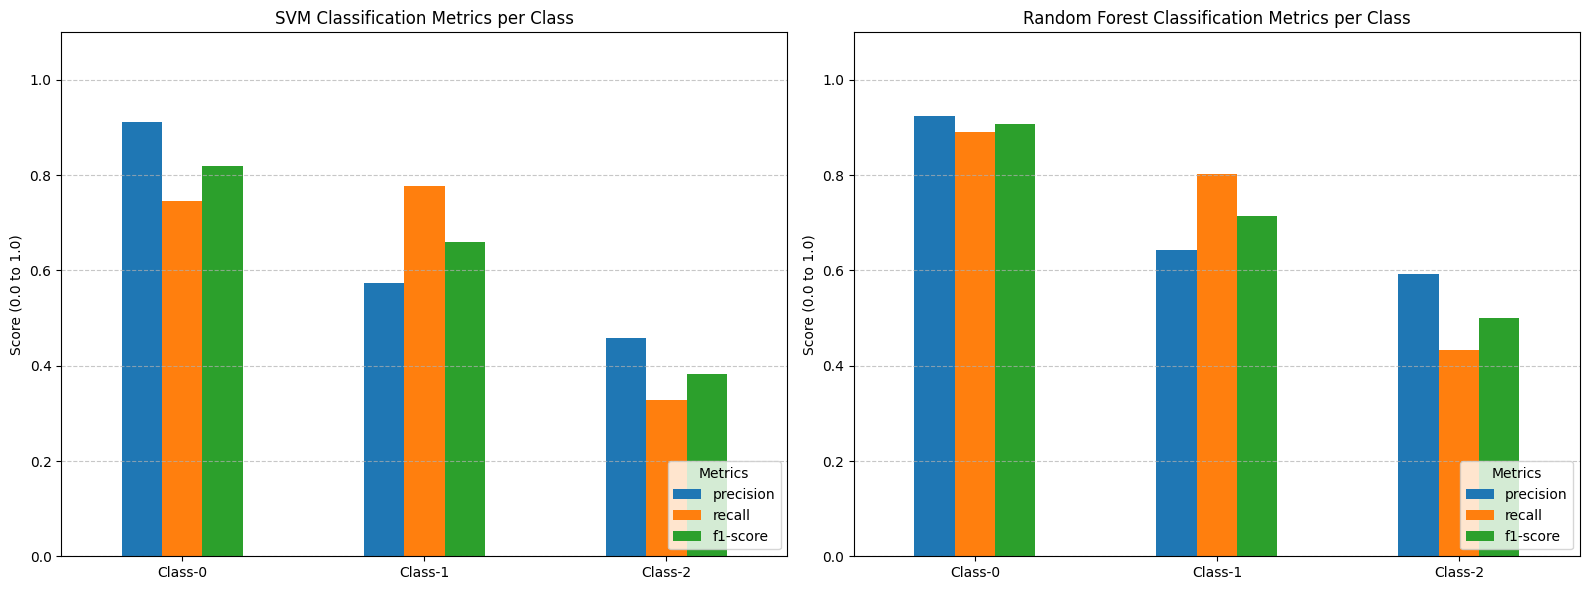

In [79]:
# 1. Output the reports as dictionaries
label_names = ['Class-0', 'Class-1', 'Class-2']
svm_report_dict = classification_report(y_test, y_pred_svm, target_names=label_names, output_dict=True)
rf_report_dict = classification_report(y_test, y_pred_rf, target_names=label_names, output_dict=True)

# 2. Convert to Pandas DataFrames
df_svm = pd.DataFrame(svm_report_dict).transpose()
df_rf = pd.DataFrame(rf_report_dict).transpose()

# 3. Filter the data for both models
classes_to_plot = ['Class-0', 'Class-1', 'Class-2']
metrics_to_plot = ['precision', 'recall', 'f1-score']

df_classes_svm = df_svm.loc[classes_to_plot, metrics_to_plot]
df_classes_rf = df_rf.loc[classes_to_plot, metrics_to_plot]

# 4. Create a figure with 1 row and 2 columns
# figsize=(16, 6) makes it wide enough to fit both comfortably
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

# 5. Draw the SVM Graph on the first axis (axes[0])
df_classes_svm.plot(kind='bar', ax=axes[0])
axes[0].set_title('SVM Classification Metrics per Class')
axes[0].set_ylabel('Score (0.0 to 1.0)')
axes[0].set_ylim(0, 1.1)
axes[0].tick_params(axis='x', rotation=0) 
axes[0].legend(loc='lower right', title='Metrics')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# 6. Draw the Random Forest Graph on the second axis (axes[1])
df_classes_rf.plot(kind='bar', ax=axes[1])
axes[1].set_title('Random Forest Classification Metrics per Class')
axes[1].set_ylabel('Score (0.0 to 1.0)')
axes[1].set_ylim(0, 1.1)
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(loc='lower right', title='Metrics')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# 7. Clean up layout and display
plt.tight_layout() # Prevents overlapping labels
plt.show()

In [80]:
# Compare Model accuracy

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))

SVM Accuracy: 0.6206896551724138
RF Accuracy: 0.7044334975369458


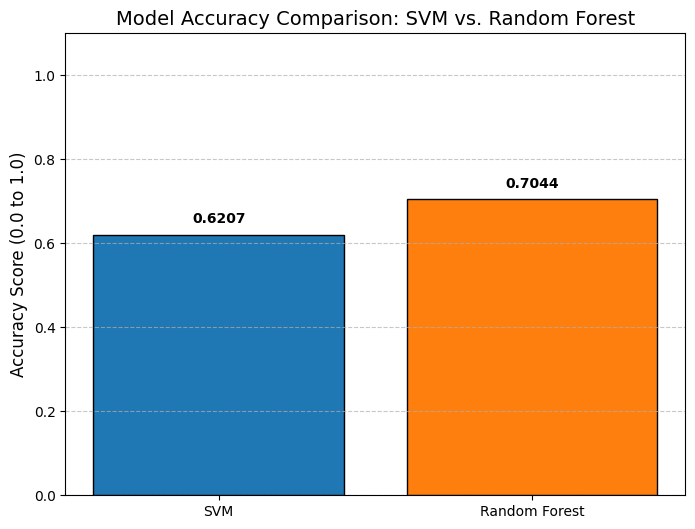

In [81]:
# Graph
# 1. Calculate your accuracies and store them in variables
svm_acc = accuracy_score(y_test, y_pred_svm)
rf_acc = accuracy_score(y_test, y_pred_rf)

# 2. Set up the data for the graph
models = ['SVM', 'Random Forest']
accuracies = [svm_acc, rf_acc]

# 3. Create the bar chart
plt.figure(figsize=(8, 6))
# You can change the colors here if you prefer a different theme
bars = plt.bar(models, accuracies, color=['#1f77b4', '#ff7f0e'], edgecolor='black')

# 4. Format the plot
plt.title('Model Accuracy Comparison: SVM vs. Random Forest', fontsize=14)
plt.ylabel('Accuracy Score (0.0 to 1.0)', fontsize=12)
plt.ylim(0, 1.1) # Set the top of the y-axis a bit higher than 1.0 for visual headroom
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 5. Add the exact accuracy text on top of each bar
for bar in bars:
    yval = bar.get_height()
    # This places the text in the middle of the bar, slightly above the top
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')

plt.show()

In [82]:
# Added Confusion Matrix

print("SVM:")
svm_confusion = confusion_matrix(y_test, y_pred_svm)
svm_confusion


SVM:


array([[41,  5,  9],
       [ 1, 63, 17],
       [ 3, 42, 22]])

In [83]:
print("Random Forest:")
rf_confusion = confusion_matrix(y_test, y_pred_rf)
rf_confusion

Random Forest:


array([[49,  2,  4],
       [ 0, 65, 16],
       [ 4, 34, 29]])

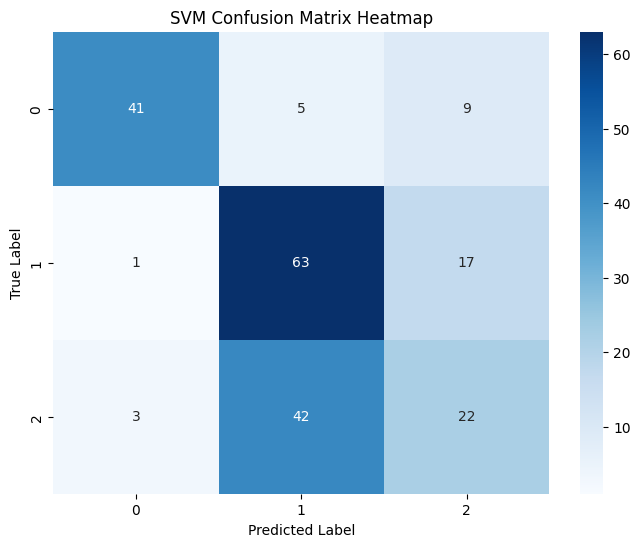

In [84]:
plt.figure(figsize=(8, 6))

# Plot the heatmap
# annot=True puts the numbers inside the squares
# fmt='g' ensures the numbers are formatted as regular integers (not scientific notation)
# cmap='Blues' sets the color theme to blue
sns.heatmap(svm_confusion, annot=True, fmt='g', cmap='Blues')

# Add titles and labels for clarity
plt.title('SVM Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Display the plot
plt.show()

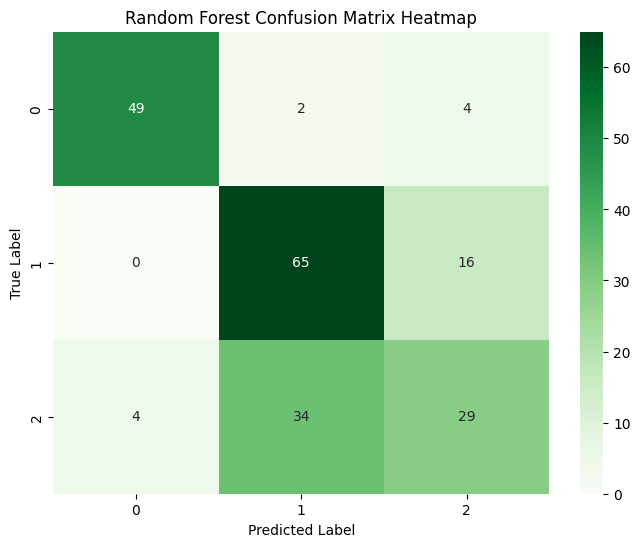

In [85]:
plt.figure(figsize=(8, 6))

# Plot the heatmap for the Random Forest confusion matrix
# Using cmap='Greens' to differentiate it from the SVM plot
sns.heatmap(rf_confusion, annot=True, fmt='g', cmap='Greens')

# Add titles and labels for clarity
plt.title('Random Forest Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Display the plot
plt.show()

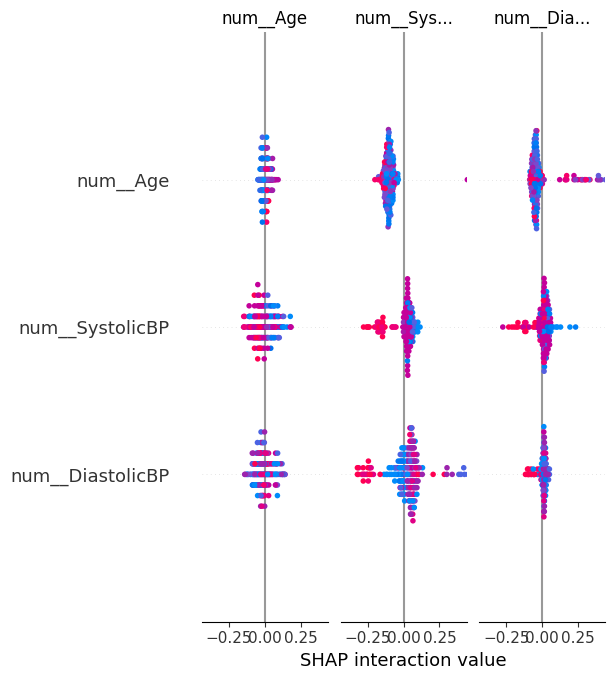

In [86]:
# SHAP

# Extract parts from pipeline
model = rf_pipeline.named_steps['model']
preprocessor = rf_pipeline.named_steps['preprocess']

# Transform your data
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Create SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_transformed)

# Get feature names
feature_names = preprocessor.get_feature_names_out()

# Summary plot
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)

In [ ]:
num_Age, num_SystolicBP, num_DiastolicBP

In [88]:
class_index = 1 

# Slice the 3D array to get a 2D array for that specific class
# The syntax [:, :, class_index] means: [all_rows, all_features, specific_class]
shap_values_2d = shap_values[:, :, class_index]

# Now pandas will happily accept it!
shap_df = pd.DataFrame(shap_values_2d, columns=feature_names)

print(f"--- Raw SHAP Values for Class {class_index} (first 5 test instances) ---")
print(shap_df.head())
print("\n")


# Calculate the Mean Absolute SHAP value for each feature for this specific class
mean_shap_values = np.abs(shap_df).mean().sort_values(ascending=False)

print(f"--- Overall Feature Importance for Class {class_index} ---")
print(mean_shap_values)

--- Raw SHAP Values for Class 1 (first 5 test instances) ---
   num__Age  num__SystolicBP  num__DiastolicBP   num__BS  num__BodyTemp  \
0  0.024917         0.039617          0.021825  0.057630       0.038438   
1  0.022232         0.014822          0.022692 -0.205660       0.034311   
2 -0.017171        -0.252220         -0.098370  0.033201       0.020307   
3  0.050176         0.057337         -0.001469  0.009220       0.051943   
4 -0.004732         0.021578          0.006663  0.141326       0.047702   

   num__HeartRate  num__sleep_hours  num__phys_activity_score  \
0        0.034239         -0.039201                 -0.001706   
1        0.039161          0.013252                  0.000911   
2       -0.018010         -0.002861                  0.001206   
3        0.013389         -0.007818                 -0.008393   
4        0.022095         -0.019522                  0.014304   

   num__stress_score  num__diet_quality_score  ...  \
0          -0.009647                -0.0029